[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eirasf/GCED-AA2/blob/main/es/lab6/lab6-parte2.ipynb)
# Práctica 6: Redes neuronales convolucionales - Complicando la CNN


### Pre-requisitos. Instalar paquetes
Usaremos las mismas librerías que para la parte 1. En esta ocasión utilizaremos la GPU, así que declaramos la variable `device`. Recuerda enviar tus modelos al device cuando los instancies (`m = MiModelo().to(device)`) y de enviar también los tensores de datos en el bucle de entrenamiento (`X_batch = X_batch.to(device)` y lo mismo para las etiquetas).

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision
from torchvision import transforms
import numpy as np
import random
import os
from matplotlib import pyplot as plt

# Semilla para reproducibilidad
seed = 1234567
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


### Carga del conjunto de datos

En esta ocasión trabajaremos con el conjunto de imágenes *cifar10*, que son imágenes con tres canales.

100%|██████████| 170M/170M [35:38<00:00, 79.7kB/s]


torch.Size([128, 3, 32, 32])
torch.Size([128])


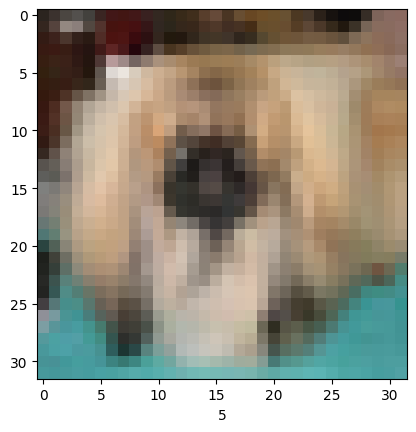

In [2]:
# Los datos de CIFAR se estandarizan utilizando su media y desviación típicas, que aquí vienen precalculadas.
cifar10_mean = (0.4914, 0.4822, 0.4465)
cifar10_std = (0.2023, 0.1994, 0.2010)

transform = transforms.Compose([
    transforms.ToTensor(),
    # TODO - Usa transforms.Normalize para estandarizar
    transforms.Normalize(mean=cifar10_mean, std=cifar10_std)
])

train_val = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)
test_set = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)

# TODO - Divide train_val en train y val (80/20)
train_size = int(0.8 * len(train_val))
val_size = len(train_val) - train_size
train_set, val_set = data.random_split(
    train_val, [train_size, val_size], generator=torch.Generator().manual_seed(seed)
)

# TODO - Crea los DataLoaders
batch_size = 128
train_loader = data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = data.DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = data.DataLoader(test_set, batch_size=batch_size, shuffle=False)

# Mostramos un ejemplo del conjunto
images, labels = next(iter(train_loader))
print(images.shape)  # [128, 3, 32, 32]
print(labels.shape)  # [128]

# Para mostrar los datos con pyplot hay que deshacer la normalización y poner los canales como última dimensión del tensor
def unnormalize(img):
    img = img.permute(1,2,0)  # CHW -> HWC
    img = img * torch.tensor(cifar10_std) + torch.tensor(cifar10_mean)
    return img.clamp(0,1)

plt.imshow(unnormalize(images[0]))
plt.xlabel(labels[0].item())
plt.show()

## Creando el modelo y entrenando el modelo
Para este problema vamos a utilizar la siguiente arquitectura:
1. [Convolución 2D](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html) de 32 filtros y tamaño de kernel 3, con activación ReLU
1. [Pooling 2D](https://docs.pytorch.org/docs/2.8/generated/torch.nn.MaxPool2d.html) tomando el máximo de cada grupo de 2x2
1. [Convolución 2D](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html) de 64 filtros y tamaño de kernel 3, con activación ReLU
1. [Pooling 2D](https://docs.pytorch.org/docs/2.8/generated/torch.nn.MaxPool2d.html) tomando el máximo de cada grupo de 2x2
1. [Convolución 2D](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html) de 64 filtros y tamaño de kernel 3, con activación ReLU
1. Capa Densa (requiere aplanado previo) de 64 unidades y activación ReLU
1. Capa de salida

Define el modelo y haz el entrenamiento como en la anterior parte.

Epoch 01/15 | Train Loss: 1.6211 Acc: 0.4062 | Val Loss: 1.3442 Acc: 0.5175
Epoch 02/15 | Train Loss: 1.2567 Acc: 0.5523 | Val Loss: 1.1796 Acc: 0.5785
Epoch 03/15 | Train Loss: 1.0797 Acc: 0.6218 | Val Loss: 1.0743 Acc: 0.6218
Epoch 04/15 | Train Loss: 0.9704 Acc: 0.6615 | Val Loss: 0.9895 Acc: 0.6480
Epoch 05/15 | Train Loss: 0.8850 Acc: 0.6913 | Val Loss: 0.9487 Acc: 0.6702
Epoch 06/15 | Train Loss: 0.8219 Acc: 0.7141 | Val Loss: 0.8914 Acc: 0.6888
Epoch 07/15 | Train Loss: 0.7608 Acc: 0.7340 | Val Loss: 0.8602 Acc: 0.7026
Epoch 08/15 | Train Loss: 0.7148 Acc: 0.7526 | Val Loss: 0.8741 Acc: 0.7009
Epoch 09/15 | Train Loss: 0.6686 Acc: 0.7668 | Val Loss: 0.8363 Acc: 0.7128
Epoch 10/15 | Train Loss: 0.6222 Acc: 0.7827 | Val Loss: 0.8724 Acc: 0.7049
Epoch 11/15 | Train Loss: 0.5916 Acc: 0.7933 | Val Loss: 0.8570 Acc: 0.7148
Epoch 12/15 | Train Loss: 0.5589 Acc: 0.8056 | Val Loss: 0.8757 Acc: 0.7082
Epoch 13/15 | Train Loss: 0.5242 Acc: 0.8172 | Val Loss: 0.8663 Acc: 0.7189
Epoch 14/15 

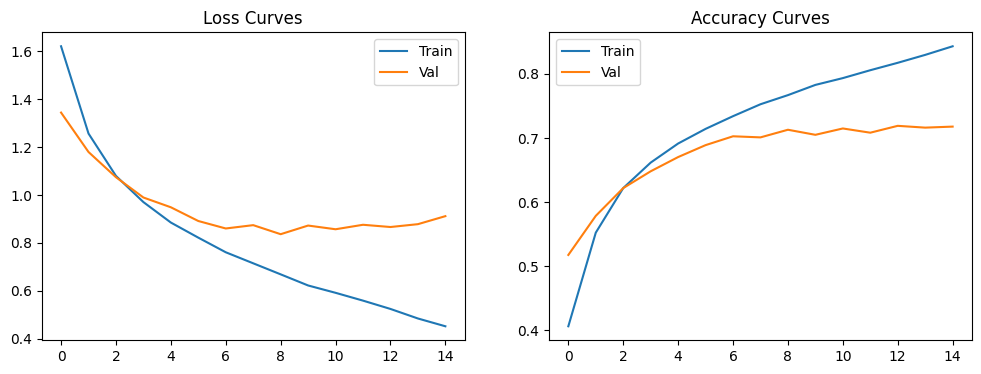

Rendimiento en TEST -> Loss: 0.9216 | Accuracy: 0.7231


In [3]:
# TODO Define el modelo
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 64, kernel_size=3, padding=0),
            nn.ReLU()
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# TODO Define las funciones de aprendizaje y evaluación
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return running_loss / total, correct / total

# TODO Realiza el entrenamiento
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 15
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    print(f"Epoch {epoch+1:02d}/{epochs:02d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

# TODO Examina las curvas de entrenamiento y mide el rendimiento en test
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, label='Train')
ax1.plot(val_losses, label='Val')
ax1.set_title('Loss Curves')
ax1.legend()

ax2.plot(train_accs, label='Train')
ax2.plot(val_accs, label='Val')
ax2.set_title('Accuracy Curves')
ax2.legend()
plt.show()

test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Rendimiento en TEST -> Loss: {test_loss:.4f} | Accuracy: {test_acc:.4f}")

Si todo ha ido bien, deberías haber obtenido una preción en test de al menos un 60%, lo cual no es desdeñable para una red sencilla.

## Mejora del rendimiento
Vuelve sobre la arquitectura del modelo e incluye capas de [BatchNorm2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html) después de cada capa convolucional. Esto hará que las salidas de esa capa se estandaricen para que sigan una distribución N(0,1) (la operación de estandarización se incluye en el grafo y, por tanto, el cómputo de los gradientes). El efecto de esta capa es que se evitará que el gradiente del lote tenga una gran componente solo dedicada a acercar las salidas a la media/desviación de las muestras en cada capa. En consecuencia, el aprendizaje se acelera.

### Ejercicios
 - Repite el entrenamiento con la nueva arquitectura. ¿Qué efecto has notado? ¿Puedes mejorar el rendimiento en test utilizando conceptos vistos en Laboratorios anteriores?
 - Prueba distintas arquitecturas e intenta mejorar el rendimiento en test.

Epoch 01/15 | Train Loss: 1.3913 Acc: 0.5120 | Val Loss: 1.0763 Acc: 0.6166
Epoch 02/15 | Train Loss: 1.0089 Acc: 0.6481 | Val Loss: 0.9216 Acc: 0.6742
Epoch 03/15 | Train Loss: 0.8723 Acc: 0.6956 | Val Loss: 0.8932 Acc: 0.6882
Epoch 04/15 | Train Loss: 0.7823 Acc: 0.7287 | Val Loss: 0.8717 Acc: 0.6928
Epoch 05/15 | Train Loss: 0.7164 Acc: 0.7519 | Val Loss: 0.8133 Acc: 0.7133
Epoch 06/15 | Train Loss: 0.6586 Acc: 0.7714 | Val Loss: 0.8127 Acc: 0.7203
Epoch 07/15 | Train Loss: 0.6146 Acc: 0.7867 | Val Loss: 0.7664 Acc: 0.7286
Epoch 08/15 | Train Loss: 0.5689 Acc: 0.8016 | Val Loss: 0.8113 Acc: 0.7264
Epoch 09/15 | Train Loss: 0.5233 Acc: 0.8161 | Val Loss: 0.7952 Acc: 0.7324
Epoch 10/15 | Train Loss: 0.4960 Acc: 0.8253 | Val Loss: 0.8723 Acc: 0.7125
Epoch 11/15 | Train Loss: 0.4519 Acc: 0.8428 | Val Loss: 0.8331 Acc: 0.7277
Epoch 12/15 | Train Loss: 0.4239 Acc: 0.8529 | Val Loss: 0.9210 Acc: 0.7134
Epoch 13/15 | Train Loss: 0.3989 Acc: 0.8591 | Val Loss: 0.8362 Acc: 0.7340
Epoch 14/15 

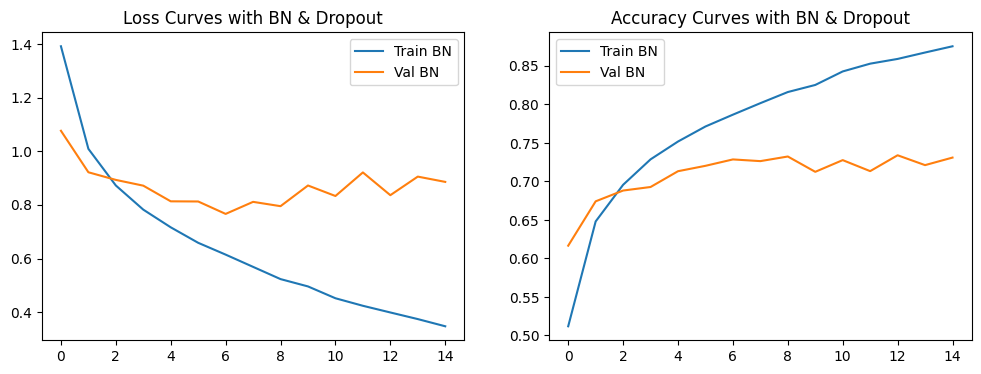

Rendimiento en TEST (con BN y Dropout) -> Loss: 0.8745 | Accuracy: 0.7447


In [4]:
# TODO Define el nuevo modelo
class BatchNormCNN(nn.Module):
    def __init__(self):
        super(BatchNormCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=0),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=0),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 64, kernel_size=3, padding=0),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# TODO Define las funciones de aprendizaje y evaluación
# Reutilizamos las funciones train_epoch y evaluate definidas anteriormente

# TODO Realiza el entrenamiento
model_bn = BatchNormCNN().to(device)
optimizer_bn = optim.Adam(model_bn.parameters(), lr=0.001)

epochs_bn = 15
train_losses_bn, val_losses_bn = [], []
train_accs_bn, val_accs_bn = [], []

for epoch in range(epochs_bn):
    train_loss, train_acc = train_epoch(model_bn, train_loader, criterion, optimizer_bn, device)
    val_loss, val_acc = evaluate(model_bn, val_loader, criterion, device)
    train_losses_bn.append(train_loss)
    val_losses_bn.append(val_loss)
    train_accs_bn.append(train_acc)
    val_accs_bn.append(val_acc)
    print(f"Epoch {epoch+1:02d}/{epochs_bn:02d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

# TODO Examina las curvas de entrenamiento y mide el rendimiento en test
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses_bn, label='Train BN')
ax1.plot(val_losses_bn, label='Val BN')
ax1.set_title('Loss Curves with BN & Dropout')
ax1.legend()

ax2.plot(train_accs_bn, label='Train BN')
ax2.plot(val_accs_bn, label='Val BN')
ax2.set_title('Accuracy Curves with BN & Dropout')
ax2.legend()
plt.show()

test_loss_bn, test_acc_bn = evaluate(model_bn, test_loader, criterion, device)
print(f"Rendimiento en TEST (con BN y Dropout) -> Loss: {test_loss_bn:.4f} | Accuracy: {test_acc_bn:.4f}")